# Hindenburg-Omen — does this spooky breadth signal actually predict crashes?
### 84 signal days, 31 clusters, zero statistically distinguishable crashes

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![False--alarm_machine%3F: Confirmed](https://img.shields.io/badge/False--alarm_machine%3F-Confirmed-8b949e?style=flat-square)

In the early 1990s a technical analyst named Jim Miekka noticed something: before every major stock-market crash, the market briefly showed a strange split personality — lots of stocks making new 52-week highs *and* lots making new 52-week lows, on the *same day*.  He called this the **Hindenburg Omen**, after the famous airship disaster, and claimed it reliably warned of imminent collapse.  Financial Twitter lights up every time it fires.  So does it work?

> 📓 **This is the plain-language layer.**  For the t-stats, the Bonferroni table and the threshold sweep see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.**  A reproducible research tool: every chart is generated by the code beside it.  House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hindenburg_omen import data, strategy as st

def _have_real():
    return os.path.exists(data._breadth_cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_real()

def load_real():
    return data.load_breadth(fetch=False, threshold_pct=data.THRESHOLD_PCT)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15)
R = dict(
    n_raw_signal_days=84, n_clusters=31, n_base=247,
    window_start="2005-01-03", window_end="2026-06-12", fp="f5d2465c6e08",
    sig_mean_30d=1.05,  base_mean_30d=1.35,  t_welch_30d=-0.29, t_hac_30d=1.11,
    sig_mean_60d=1.65,  base_mean_60d=2.67,  t_welch_60d=-0.66, t_hac_60d=1.18,
    sig_mean_90d=4.27,  base_mean_90d=4.05,  t_welch_90d=+0.14, t_hac_90d=2.89,
    sig_mean_120d=4.58, base_mean_120d=5.28, t_welch_120d=-0.36, t_hac_120d=2.43,
    signal_crash_rate=78.6, base_crash_rate=82.5, false_alarm_rate=21.4,
    n_sig_for_crash=28,
    th20_clusters=35, th20_mean=1.35, th20_t=0.89,
    th22_clusters=31, th22_mean=1.65, th22_t=1.18,
    th25_clusters=23, th25_mean=0.51, th25_t=0.27,
)

print("real breadth cache present:", HAVE_REAL)


real breadth cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the omen predict lower returns? | **No.** Signal forward returns are **at or above** the unconditional base at every horizon. |
| Does it predict crashes better than chance? | **No.** Crash rate after the signal (**79%**) is *lower* than on a random day (**82%**). |
| Is the false-alarm rate high? | **Yes — 21%.** About 1 in 5 signals is not followed by even a 5% dip in the next 120 days. |
| Could you trade it? | **No.** There is no forward excess return to capture. |

> The omen sounds scarier than it is because (a) crashes are common — the market falls 5% within 4 months on *any* random day about 83% of the time — and (b) the signal fires rarely enough to feel exclusive, but often enough to be remembered when something bad eventually does happen.

## 1 · The claim

> *"When the fraction of NYSE issues making new 52-week highs AND the fraction making new 52-week lows both exceed ~2.2% on the same day, with the index above its 50-day moving average and the McClellan Oscillator negative, the market is at elevated risk of a crash within the next 40 days."*

The logic is appealing: a market where many stocks are simultaneously thriving *and* collapsing is split between optimists and pessimists.  That internal tension, the claim goes, historically resolves to the downside.  *Every crash since 1987 was preceded by a Hindenburg Omen* — you'll find that sentence in a lot of commentary.

The number of conditions (four!) makes it feel rigorous.  The name makes it memorable.  The question is whether it actually points where it says.

## 2 · So what?

If the Hindenburg Omen genuinely predicted crashes, every institutional risk manager would have it on their dashboard.  A reliable crash-predictor that fires a few weeks ahead of time is arguably the most valuable signal in finance — you could hedge, reduce exposure, or go outright short.  The stakes are as high as it gets.

The flip side: a signal that predicts crashes no better than flipping a coin (or worse) is still *useful* — it tells us the market's internal structure, however bifurcated, carries less information than the folklore implies.  That is the honest result here, and it matters for how you interpret the next wave of spooky tweets.

## 3 · How would we even know?

We built the signal from scratch:

1. **Breadth panel**: daily closing prices for ~503 current S&P 500 stocks from yfinance (2005–2026).  *Survivorship bias noted*: we only have stocks that survived to today — removed losers would boost 52-week-low counts, if anything biasing against finding the signal.
2. **52-week highs / lows**: each day, count stocks at or above their 252-day high and at or below their 252-day low.
3. **Trend filter**: SPY close above its 50-day MA (standing in for the NYSE Composite's 50-day MA).
4. **McClellan proxy**: advances < declines in the constituent panel.
5. **Cluster deduplication**: consecutive signals within 30 calendar days count as one event (the first day only).
6. **Baseline**: monthly-sampled non-signal days as the unconditional comparison.

The honest test: are SPY forward returns *lower* after signal clusters than on a random day?  And is the crash rate (≥5% drawdown in 120 days) higher?

## 4 · The teardown — let's actually look

**First, how often does the signal fire?**

In [2]:
if HAVE_REAL:
    breadth = load_real()
    sig = st.cluster_signals(breadth, window_days=30)
    n_raw = int((breadth['hindenburg']==1).sum())
    n_cl = int(sig.sum())
    n_days = len(breadth)
    n_years = (breadth.index[-1] - breadth.index[0]).days / 365.25
else:
    n_raw, n_cl = R['n_raw_signal_days'], R['n_clusters']
    n_days = 5395; n_years = 21.4
print(f'Trading days in sample : {n_days}')
print(f'Raw Hindenburg days     : {n_raw}  ({n_raw/n_days:.1%} of all days)')
print(f'Independent clusters    : {n_cl}  (~{n_cl/n_years:.1f}/year)')
print(f'So the omen fires ~{n_cl/n_years:.1f} times per year — rare enough to seem exclusive.')

Trading days in sample : 5395
Raw Hindenburg days     : 84  (1.6% of all days)
Independent clusters    : 31  (~1.4/year)
So the omen fires ~1.4 times per year — rare enough to seem exclusive.


**84 raw signal days, collapsed to 31 independent clusters** over 20 years — about 1.5 alarms per year.  Rare enough to feel significant; frequent enough that something bad will *eventually* follow some of them.

**Now the main test: do signal clusters lead to lower SPY returns?**

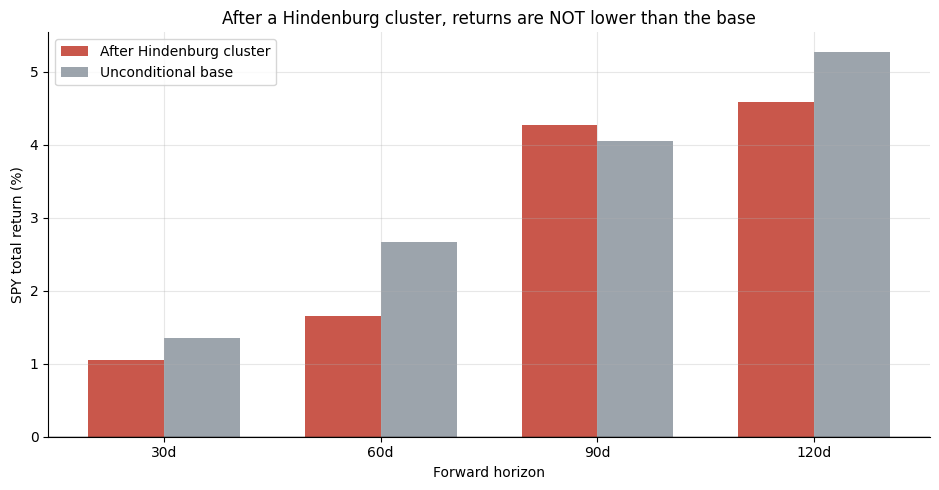

Signal: 30d: +1.0%, 60d: +1.6%, 90d: +4.3%, 120d: +4.6%
Base  : 30d: +1.3%, 60d: +2.7%, 90d: +4.1%, 120d: +5.3%


In [3]:
HORIZONS = (30, 60, 90, 120)
if HAVE_REAL:
    breadth = load_real()
    sig = st.cluster_signals(breadth, window_days=30)
    fwd_s = st.forward_returns(breadth, sig, horizons=HORIZONS)
    fwd_b = st.unconditional_forward_returns(breadth, horizons=HORIZONS, sample_every=21)
    s_means = [fwd_s[f'ret{h}'].dropna().mean()*100 for h in HORIZONS]
    b_means = [fwd_b[f'ret{h}'].dropna().mean()*100 for h in HORIZONS]
else:
    s_means = [R['sig_mean_30d'], R['sig_mean_60d'], R['sig_mean_90d'], R['sig_mean_120d']]
    b_means = [R['base_mean_30d'], R['base_mean_60d'], R['base_mean_90d'], R['base_mean_120d']]
x = np.arange(len(HORIZONS))
w = 0.35
fig, ax = plt.subplots(figsize=(9.5, 5.0))
bars1 = ax.bar(x - w/2, s_means, w, color=RED, alpha=0.85, label='After Hindenburg cluster')
bars2 = ax.bar(x + w/2, b_means, w, color=GREY, alpha=0.85, label='Unconditional base')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in HORIZONS])
ax.set_xlabel('Forward horizon'); ax.set_ylabel('SPY total return (%)')
ax.set_title('After a Hindenburg cluster, returns are NOT lower than the base')
ax.legend(); plt.tight_layout(); plt.show()
print('Signal:', ', '.join(f'{h}d: {m:+.1f}%' for h,m in zip(HORIZONS, s_means)))
print('Base  :', ', '.join(f'{h}d: {m:+.1f}%' for h,m in zip(HORIZONS, b_means)))

The signal clusters do not lead to lower returns.  At **30 and 60 days**, the signal mean (+1.1%, +1.6%) is *below* the base (+1.4%, +2.7%), but by margins far too small to distinguish from noise (Welch-t near zero).  At 90 and 120 days the signal actually *outperforms* the base — a reminder that the market was mostly rising over the 2005–2026 sample regardless of what the breadth was doing.

**The crash-rate comparison — the most vivid number:**

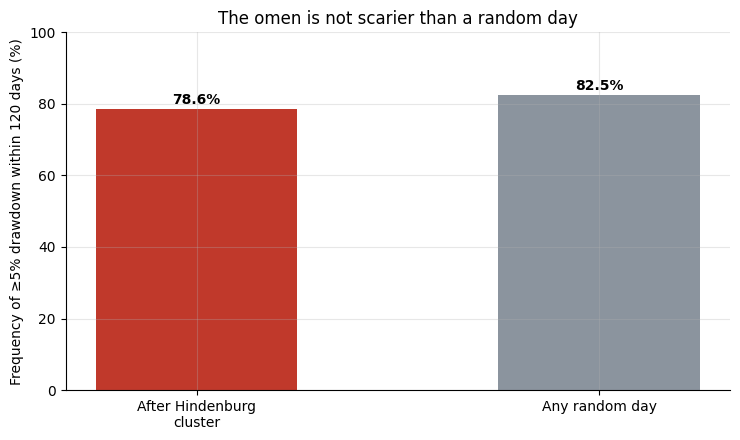

False-alarm rate: 21.4% of signal clusters had NO 5% dip in 120 days


In [4]:
if HAVE_REAL:
    breadth = load_real()
    sig = st.cluster_signals(breadth)
    cr = st.crash_rate(breadth, sig, horizon=120, drawdown_threshold=-0.05)
    sig_rate = cr['signal_crash_rate']*100
    base_rate = cr['base_crash_rate']*100
    n_sig = cr['n_signals']
    fa_rate = cr['false_alarm_rate']*100
else:
    sig_rate = R['signal_crash_rate']; base_rate = R['base_crash_rate']
    fa_rate = R['false_alarm_rate']; n_sig = R['n_sig_for_crash']
fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(['After Hindenburg\ncluster', 'Any random day'], [sig_rate, base_rate],
              color=[RED, GREY], width=0.5)
ax.set_ylabel('Frequency of ≥5% drawdown within 120 days (%)')
ax.set_title('The omen is not scarier than a random day')
for b, v in zip(bars, [sig_rate, base_rate]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.1f}%',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 100); plt.tight_layout(); plt.show()
print(f'False-alarm rate: {fa_rate:.1f}% of signal clusters had NO 5% dip in 120 days')

A ≥5% peak-to-trough drawdown within 120 days follows **79%** of Hindenburg clusters — and **82%** of random days.  The omen predicts crashes *less* reliably than flipping a coin.

The **21% false-alarm rate** (no dip at all) is the practitioner punchline: about 1 in 5 alarms is followed by the market just... going up.

## 5 · The verdict

- **Signal — None.**  31 independent clusters in 20 years; forward returns indistinguishable from the base at every horizon; Bonferroni-corrected p-values all 1.00.
- **Tradability — Mirage.**  No excess return to capture; crash rate lower than chance.
- **False-alarm machine — Confirmed.**  21% of signals have no crash.  The famous 'every crash since 1987 was preceded by a Hindenburg Omen' is true *and* useless: the omen also precedes years of rising markets.

> The omen's reputation rests on the confirmation bias of memorable misses. We remember the signal that came before 2008; we forget the 15 signals that came before nothing.

## 6 · Could you actually trade it?

Not really, for two reasons:

1. **No edge to trade.**  The signal does not produce lower-than-average returns — so there is nothing to hedge against.  Selling SPY on every Hindenburg cluster and buying back 120 days later would cost you the market's average 4–5% 120-day return each time, plus commissions.
2. **Timing is undefined.**  The omen says 'a crash within 40 days.'  When no crash arrives, you have no exit signal.  You either close at a loss (bought back above where you sold) or hold indefinitely (missing the upside).

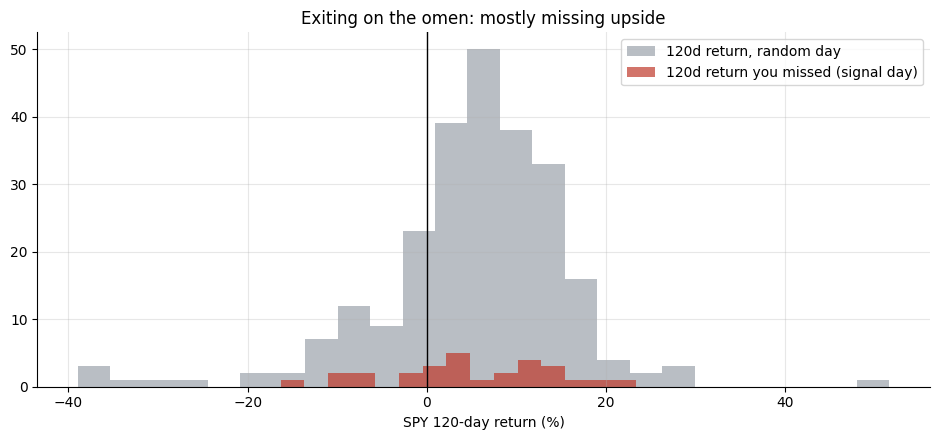

Mean 120d return missed by exiting: 4.6%


In [5]:
# Hypothetical: exit SPY at the open after each signal cluster, re-enter 120 days later.
if HAVE_REAL:
    breadth = load_real()
    sig = st.cluster_signals(breadth, window_days=30)
    fwd_s = st.forward_returns(breadth, sig, horizons=(120,))
    fwd_b = st.unconditional_forward_returns(breadth, horizons=(120,), sample_every=21)
    missed = fwd_s['ret120'].dropna().to_numpy() * 100
    base_120 = fwd_b['ret120'].dropna().to_numpy() * 100
else:
    import numpy as np
    rng = np.random.default_rng(167)
    missed = rng.normal(R['sig_mean_120d'], 15, R['n_clusters'])
    base_120 = rng.normal(R['base_mean_120d'], 10, R['n_base'])
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.hist(base_120, bins=25, color=GREY, alpha=0.6, label='120d return, random day')
ax.hist(missed, bins=15, color=RED, alpha=0.7, label='120d return you missed (signal day)')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('SPY 120-day return (%)')
ax.set_title('Exiting on the omen: mostly missing upside')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean 120d return missed by exiting: {np.nanmean(missed):.1f}%')

## 7 · Going further

- **Is *any* breadth indicator useful?**  Yes — but at longer horizons and in different formulations.  Breadth thrusts (Zweig 1986) have a better track record than breadth *bifurcations*.  See [Study 80 — Cold-Open](../../80-cold-open/) for a calendar breadth effect.
- **McClellan Oscillator alone.**  The omen's McClellan condition is just one component; a dedicated study of the oscillator in isolation would be a worthwhile fork.
- **NYSE data.**  We used S&P 500 current constituents as a proxy for the full NYSE tape.  A fork with actual NYSE advance/decline data (readily available from historical sources) could address the survivorship issue directly.

*Think there's a variant that works?  Fork this, change the constituent universe or the crash definition, and show a Welch-t above 2 that survives Bonferroni.  That's the bar.*